# 1.Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load and Explore Dataset

In [2]:
df = pd.read_csv(r"C:\Users\telug\Downloads\car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


# 3.Dataset Information and Structure

In [3]:
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())
print(df.dtypes)

(301, 9)
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
dtype: object


# 4.Data Preprocessing and Encoding Categorical Variables

In [13]:
from datetime import datetime

current_year = datetime.now().year

df['Car_Age'] = current_year-df['Year']
df_model = df.drop(['Car_Name', 'Year'], axis=1)

df_model = pd.get_dummies(df_model, drop_first=True)

print(df_model.shape)
df_model.head()

(301, 9)


,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


# 5.Exploratory Data Analysis

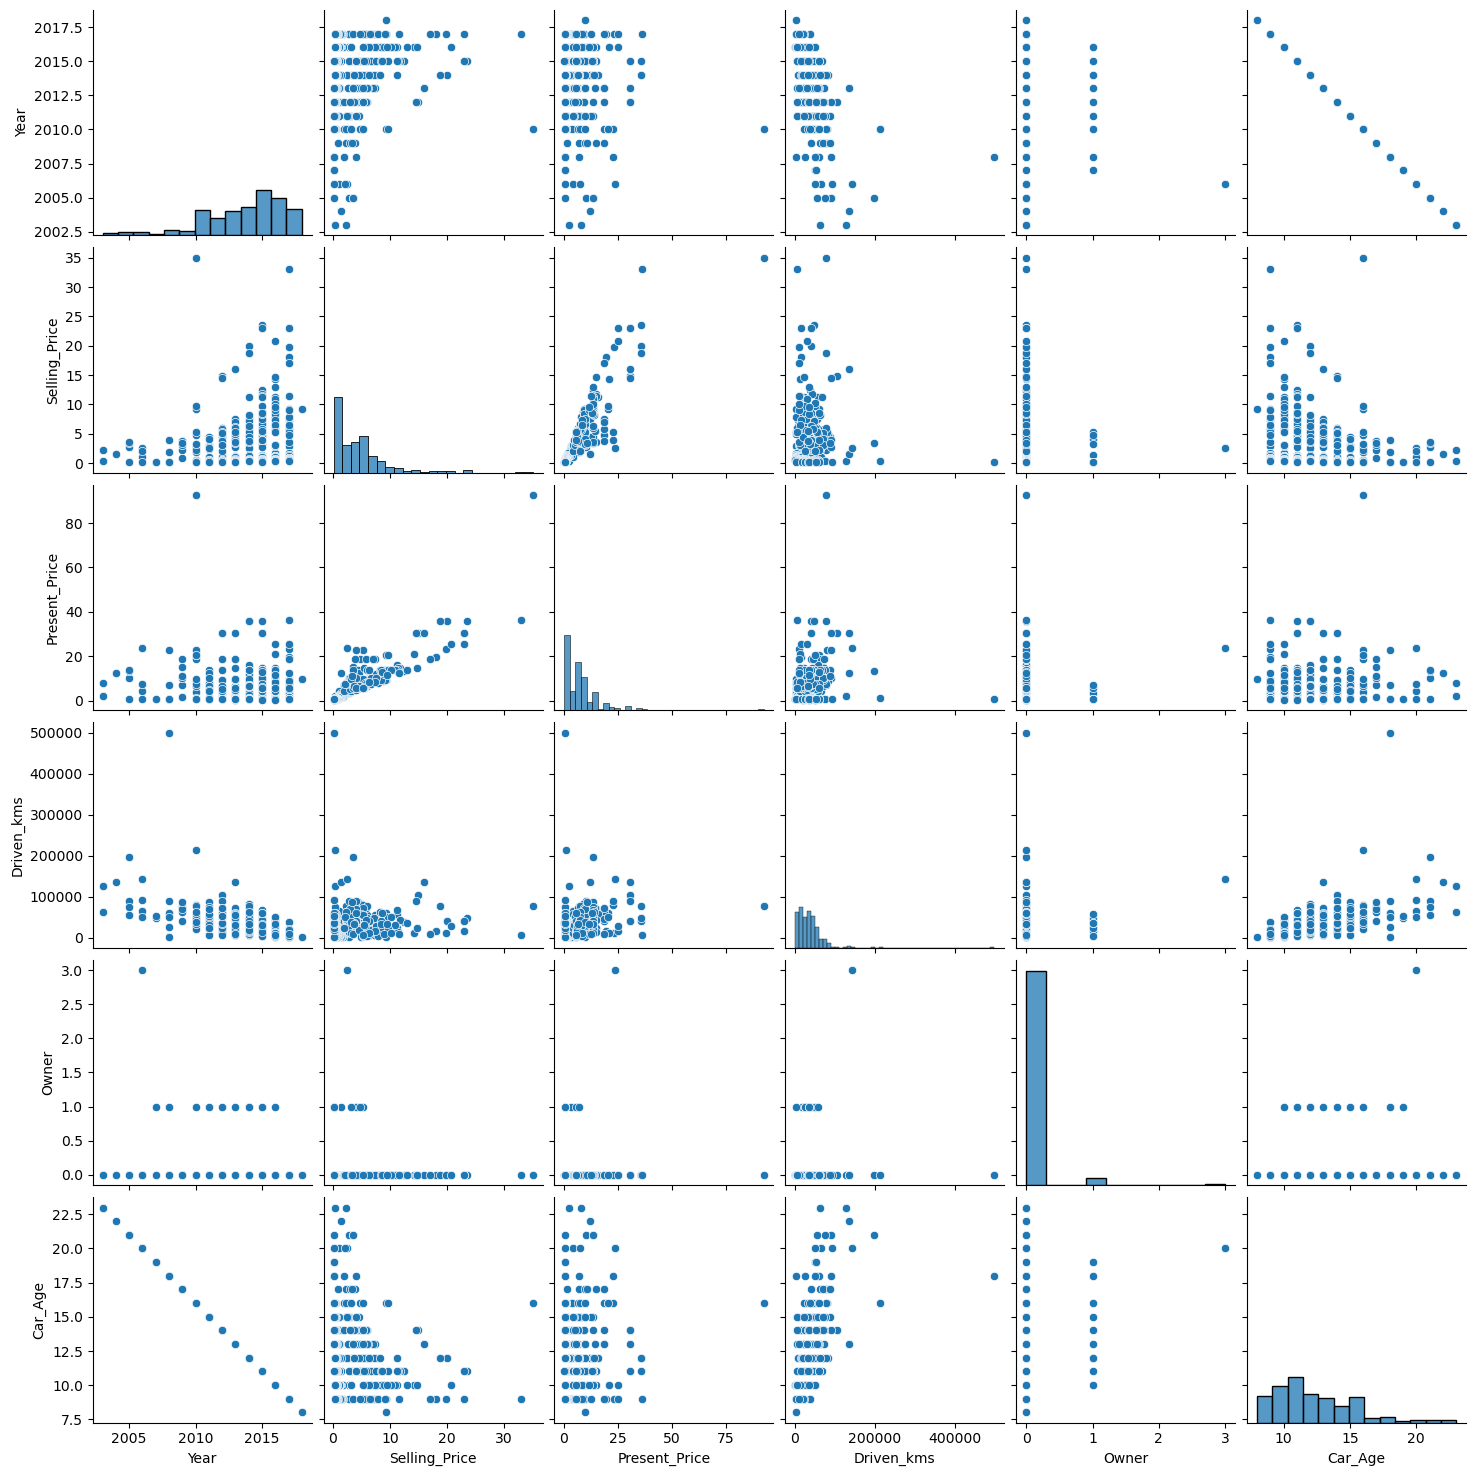

In [12]:
df.describe()
sns.pairplot(df)

<Axes: ylabel='Selling_Price'>

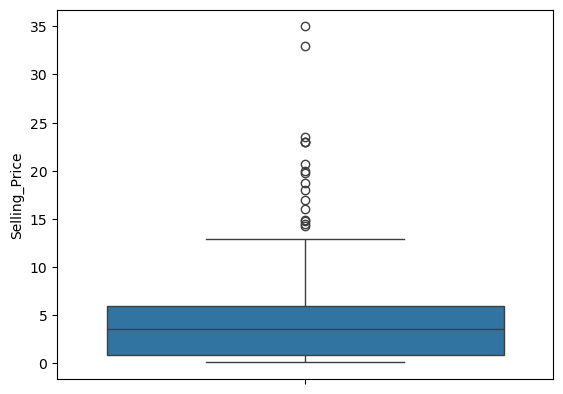

In [14]:
sns.boxplot(y=df['Selling_Price'])

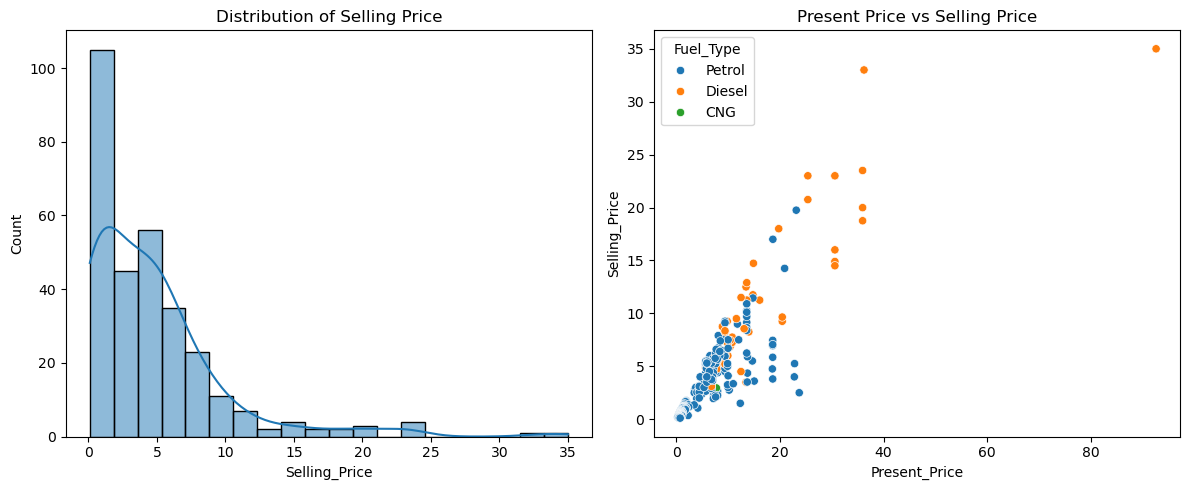

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Selling_Price'], bins=20, kde=True)
plt.title('Distribution of Selling Price')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Present_Price', y='Selling_Price', hue='Fuel_Type')
plt.title('Present Price vs Selling Price')

plt.tight_layout()
plt.show()

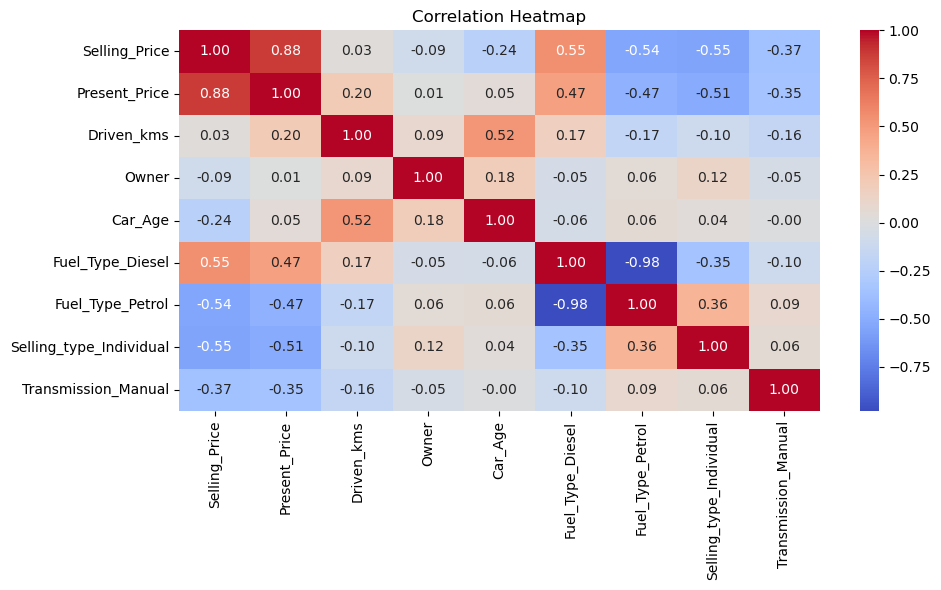

In [7]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_model.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# 6.Train/Test Split

In [8]:
from sklearn.model_selection import train_test_split

X = df_model.drop('Selling_Price', axis=1)
y = df_model['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (240, 8)
Testing set size: (61, 8)


# 7.Model Comparison and Evaluation Metrics

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

reg_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

for name, model in reg_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"{name} — R² Score: {r2:.3f}, RMSE: {rmse:.3f}")

Linear Regression — R² Score: 0.849, RMSE: 1.866
Random Forest — R² Score: 0.959, RMSE: 0.966


# 8.Feature Importance

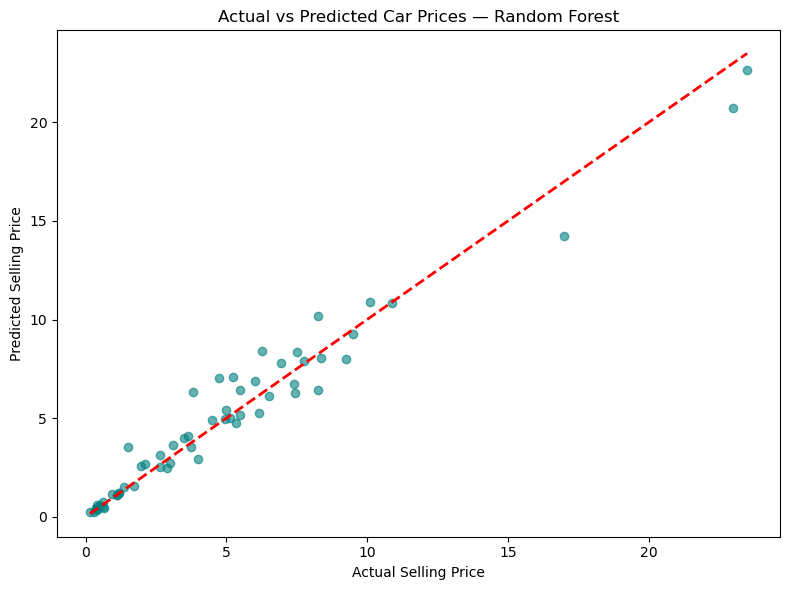

In [10]:
best_model = reg_models['Random Forest']
y_pred = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Car Prices — Random Forest')
plt.tight_layout()
plt.show()

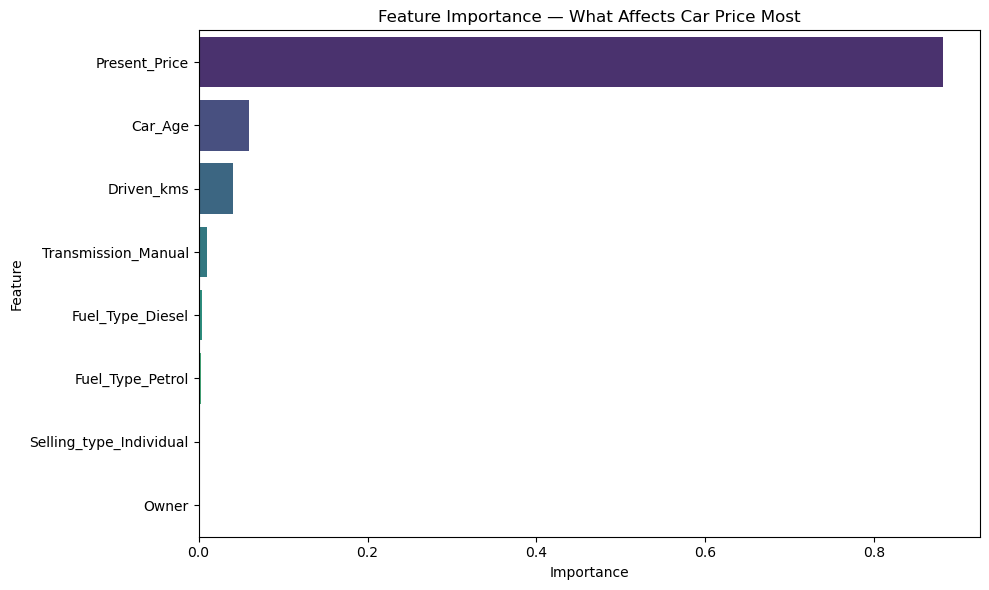

                   Feature  Importance
0            Present_Price    0.881166
3                  Car_Age    0.059495
1               Driven_kms    0.040265
7      Transmission_Manual    0.009646
4         Fuel_Type_Diesel    0.004339
5         Fuel_Type_Petrol    0.002564
6  Selling_type_Individual    0.002155
2                    Owner    0.000370


In [15]:
importances = best_model.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feat_df,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)
plt.title('Feature Importance — What Affects Car Price Most')
plt.tight_layout()
plt.show()

print(feat_df)